In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud

from pyBigKinds.preprocessing import keyword_dataframe

import math
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import os
os.chdir("../../model/bipolar_disorder")

topic_df = pd.read_excel("topic_name_bipolar.xlsx", engine="openpyxl")
topic_df = topic_df[["Group", "Topic Name","Topic"]]

all_df = pd.read_excel("df_bipolar.xlsx", engine="openpyxl")
all_df.columns = ["name", "press", "date", "keywords", "year"]

doc_df = pd.read_excel("doc_topics_bipolar.xlsx", engine="openpyxl")
doc_df = doc_df[["name", "Document", "Topic"]]

analysis_df = pd.merge(doc_df, all_df[["name", "press", "year"]], how="left")
analysis_df = analysis_df.drop_duplicates(["name", "Document", "press"])

df = pd.merge(analysis_df, topic_df, on='Topic')
df["year_range"] = df["year"].apply(lambda x: math.floor(x/10)*10)

In [3]:
conditions = [
    (df["press"].str.contains("조선일보")),
    (df["press"].str.contains("동아일보")),
    (df["press"].str.contains("한겨레")),
    (df["press"].str.contains("경향신문")),
    (df["press"].str.contains("한국일보")),
    (df["press"].str.contains("서울신문")),
]
choices = ["보수", "보수", "진보", "진보", "중도", "중도"]

df["Partizanship"] = np.select(conditions, choices, default='Other')

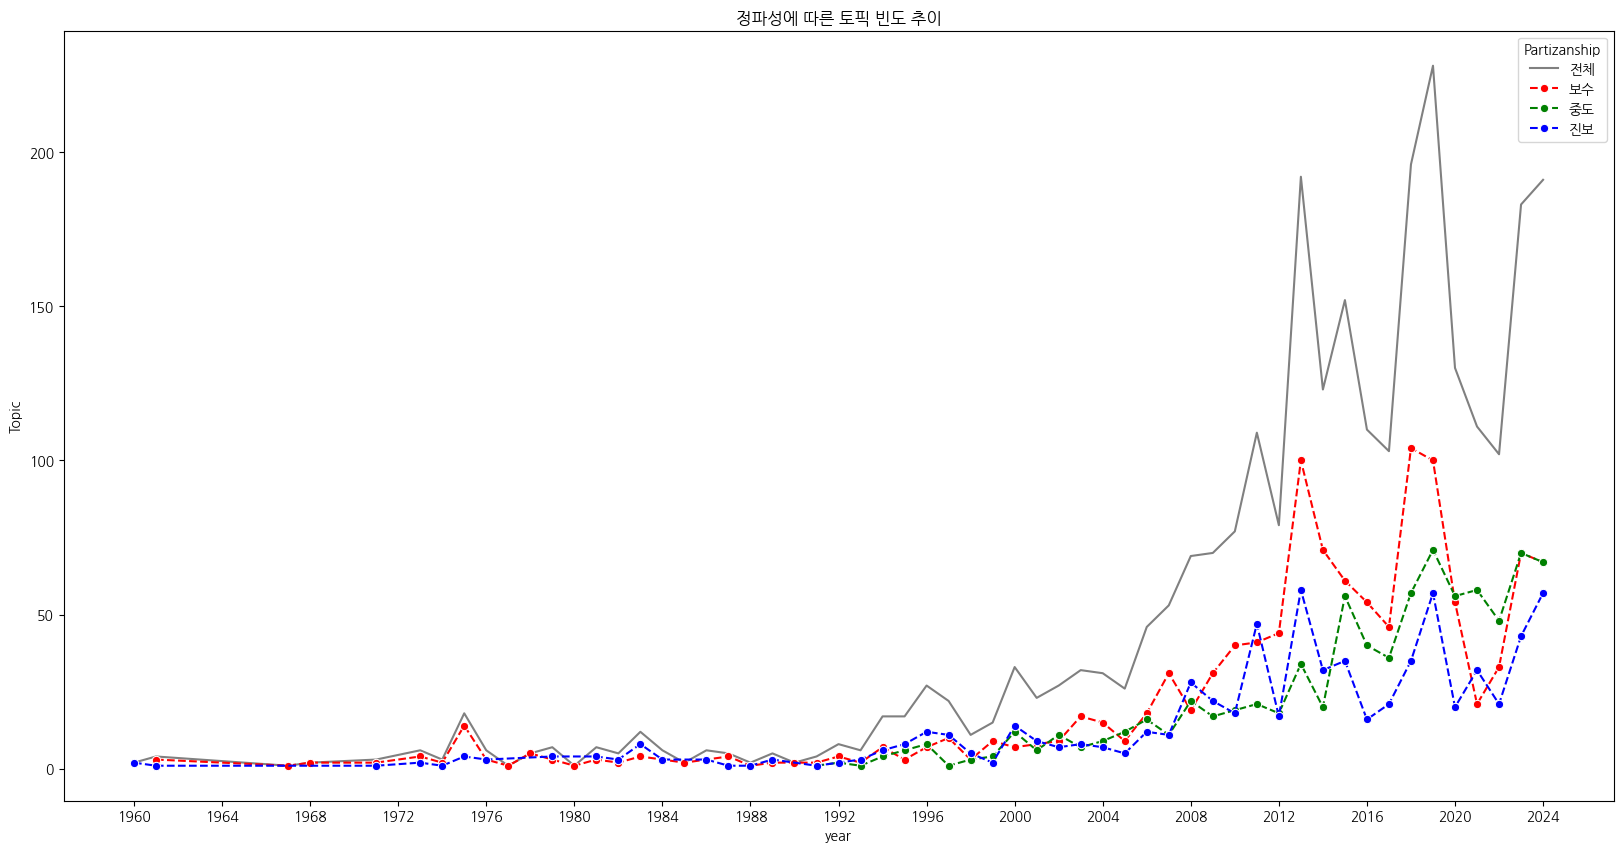

In [ ]:
tmp1 = df[df['Topic Name'] != '손예진 양극성 장애 고백'].groupby("year").count()
tmp2 = df[df['Topic Name'] != '손예진 양극성 장애 고백'].groupby(["year", "Partizanship"]).count().sort_values("Topic", ascending=False).reset_index()


plt.figure(figsize=(20, 10))

sns.lineplot(data=tmp1, x = "year", y = "Topic", label="전체", color="gray", linestyle='-')
sns.lineplot(data=tmp2, x = "year", y = "Topic", hue="Partizanship", palette=["red", "green", "blue"], linestyle='--',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.title("정파성에 따른 토픽 빈도 추이")
plt.show()

In [5]:
df[df["Topic Name"].str.contains("사건")].groupby('Topic Name').count()

,name,Document,Topic,press,year,Group,year_range,Partizanship
Topic Name,,,,,,,,
양극성 장애와 사회적 사건,2466,2466,2466,2466,2466,2466,2466,2466
유진 박 사건,60,60,60,60,60,60,60,60


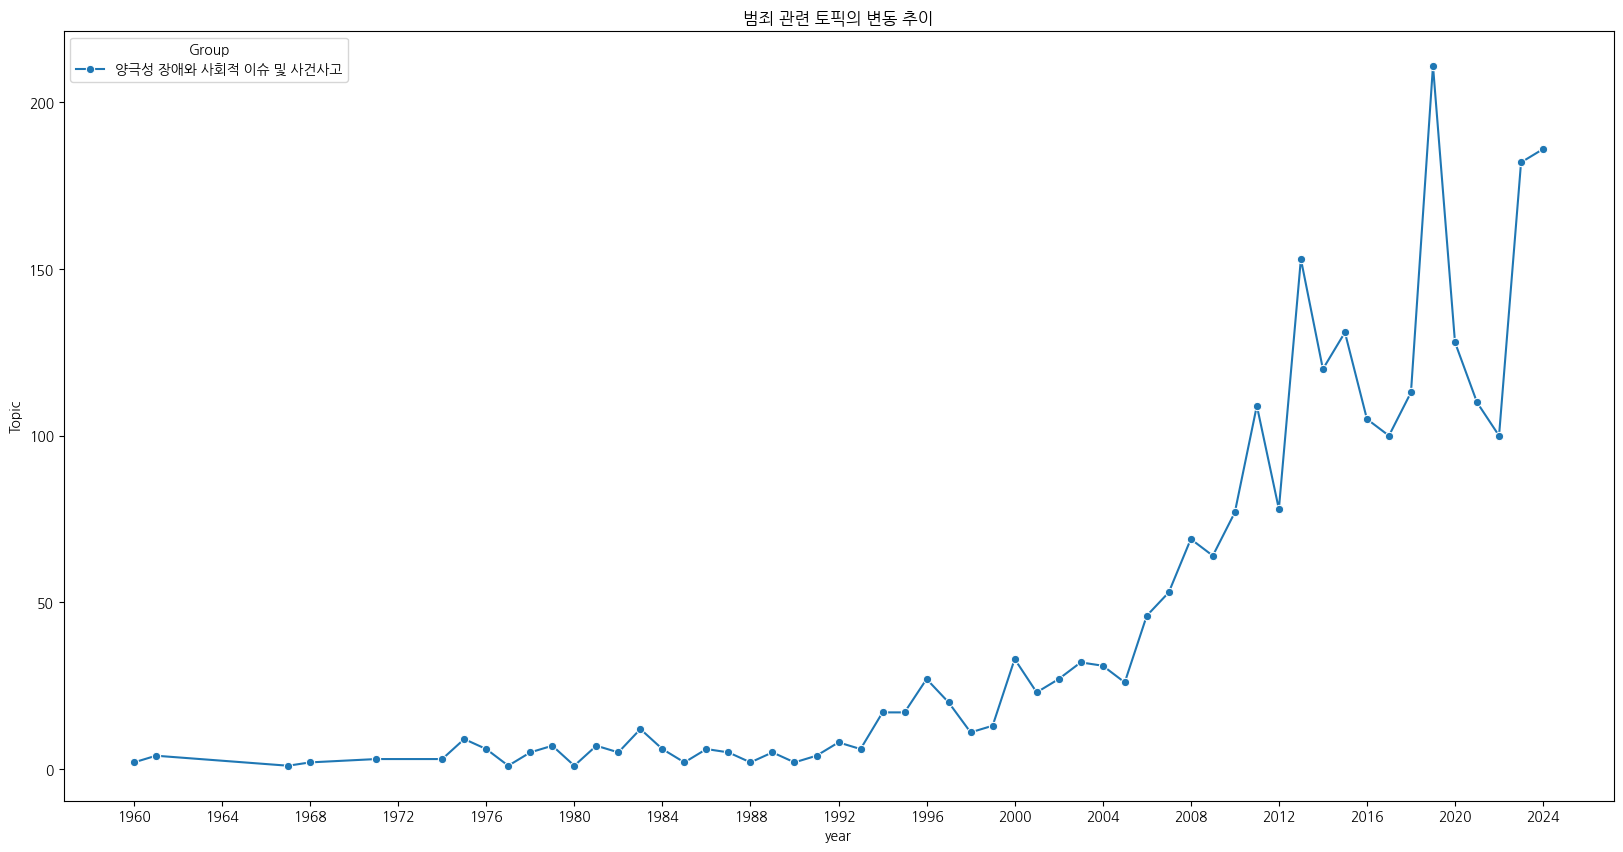

In [6]:
tmp = df[df["Topic Name"].str.contains("사건")]\
    .groupby(["year", "Group"]).count().sort_values("Topic", ascending=False).reset_index()

plt.figure(figsize=(20, 10))

sns.lineplot(data=tmp, x = "year", y = "Topic", hue = "Group", linestyle='-',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.title("범죄 관련 토픽의 변동 추이")
plt.show()

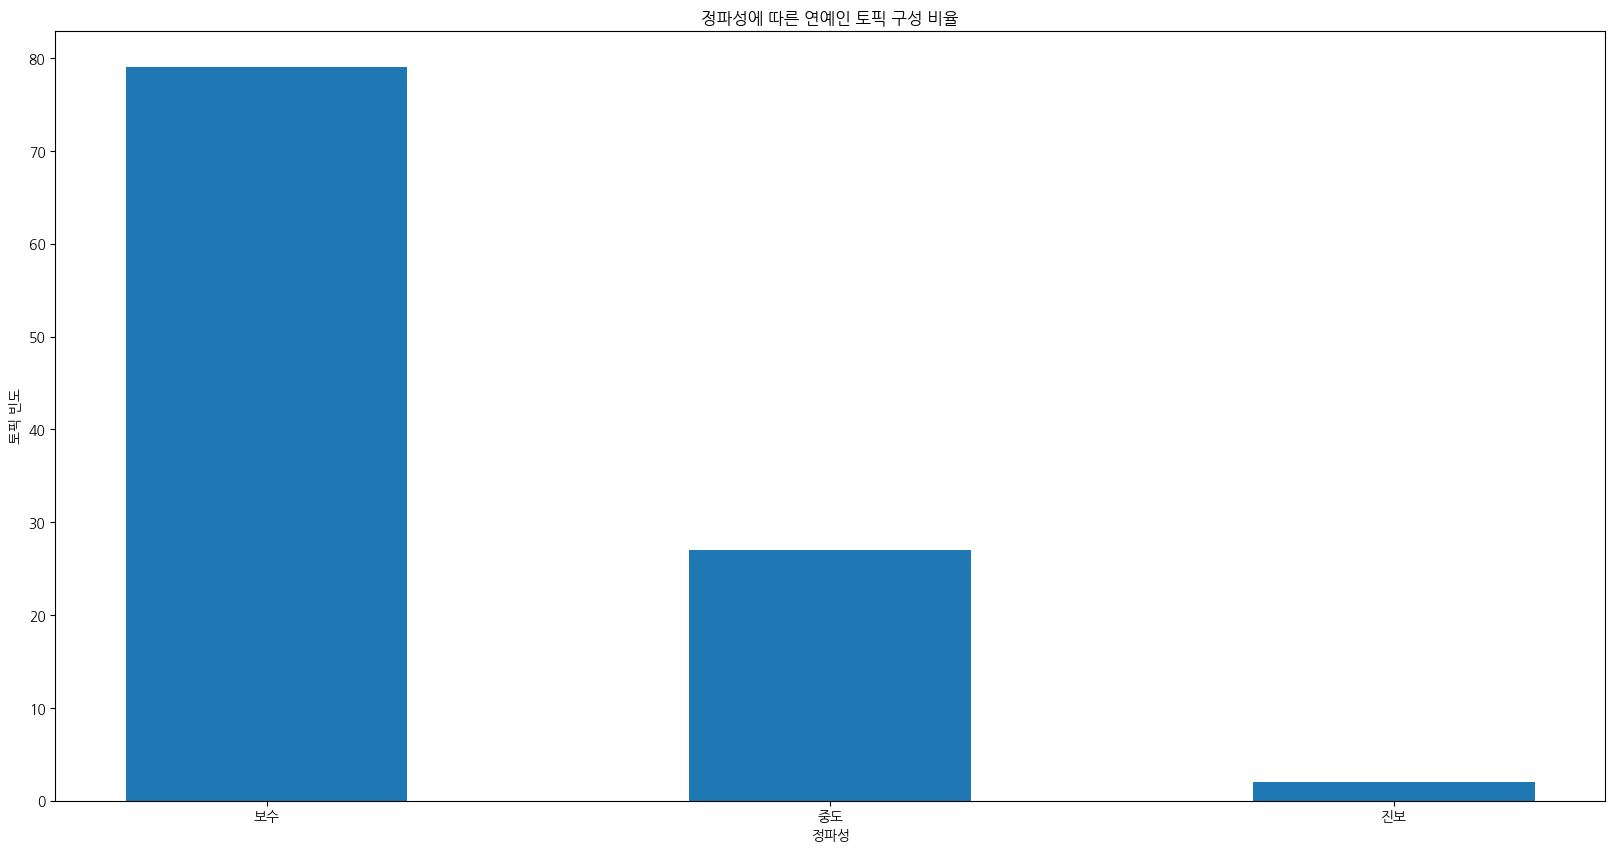

In [7]:
tmp = df[df["Group"].str.contains("연예인")].groupby("Partizanship").count().sort_values("Topic", ascending=False).reset_index()

plt.figure(figsize=(20, 10))
ind = np.arange(len(tmp))
width = 0.5

plt.bar(tmp['Partizanship'], tmp['Group'], width, label='사회적 이슈와 사건사고')

plt.xlabel('정파성')
plt.ylabel('토픽 빈도')
plt.title('정파성에 따른 연예인 토픽 구성 비율')
plt.show()

In [8]:
tmp1 = df[df["Partizanship"]=="진보"].groupby("Topic Name").count().sort_values("name", ascending=False).reset_index()
tmp2 = df[df["Partizanship"]=="보수"].groupby("Topic Name").count().sort_values("name", ascending=False).reset_index()
tmp3 = df[df["Partizanship"]=="중도"].groupby("Topic Name").count().sort_values("name", ascending=False).reset_index()

tmp_merged = pd.concat([tmp1[["Topic Name", "name"]], tmp2[["Topic Name", "name"]], tmp3[["Topic Name", "name"]]], axis=1)

tmp_merged.columns = ["진보 상위 토픽", "진보 토픽 빈도", "보수 상위 토픽", "보수 토픽 빈도", "중도 상위 토픽", "중도 토픽 빈도"]

tmp_merged.style.set_caption("정파성 별 양극성 장애 토픽 기사 빈도")

,진보 상위 토픽,진보 토픽 빈도,보수 상위 토픽,보수 토픽 빈도,중도 상위 토픽,중도 토픽 빈도
0,양극성 장애와 사회적 사건,687.000000,양극성 장애와 사회적 사건,1031,양극성 장애와 사회적 사건,748
1,정치인과 양극성 장애 관련 주제,17.000000,장근석 사회복무요원 복무,42,정치인과 양극성 장애 관련 주제,22
2,김승연 회장 구속 집행정지,10.000000,유진 박 사건,37,유진 박 사건,18
3,양극성 장애와 모자보건법,5.000000,김승연 회장 구속 집행정지,26,스윙스의 의병 제대,12
4,유진 박 사건,5.000000,손예진 양극성 장애 고백,24,장근석 사회복무요원 복무,12
5,장근석 사회복무요원 복무,2.000000,정치인과 양극성 장애 관련 주제,21,김승연 회장 구속 집행정지,8
6,nan,nan,양극성 장애와 모자보건법,14,양극성 장애와 모자보건법,4
7,nan,nan,스윙스의 의병 제대,13,손예진 양극성 장애 고백,3


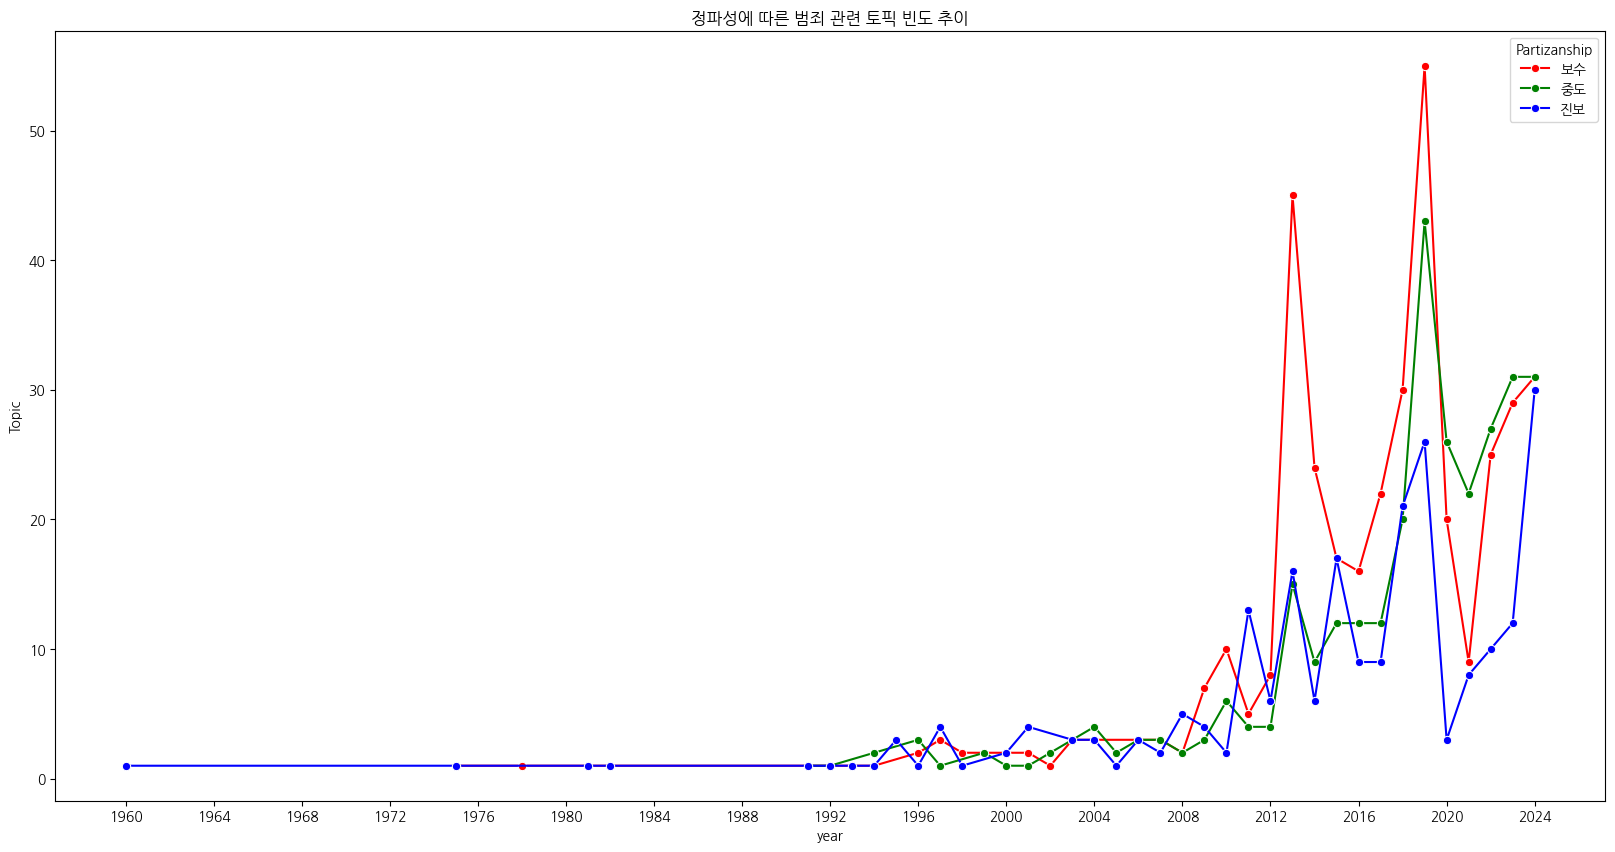

In [9]:
tmp = df[df["Group"]=="양극성 장애와 사회적 이슈 및 사건사고"]
tmp = tmp[tmp["Document"].str.contains("범행") | tmp["Document"].str.contains("혐의") | tmp["Document"].str.contains("사건")]\
    .groupby(["year", "Partizanship"]).count().sort_values("Topic", ascending=False).reset_index()

plt.figure(figsize=(20, 10))

sns.lineplot(data=tmp, x = "year", y = "Topic", hue="Partizanship", palette=["red", "green", "blue"], linestyle='-',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.title("정파성에 따른 범죄 관련 토픽 빈도 추이")
plt.show()

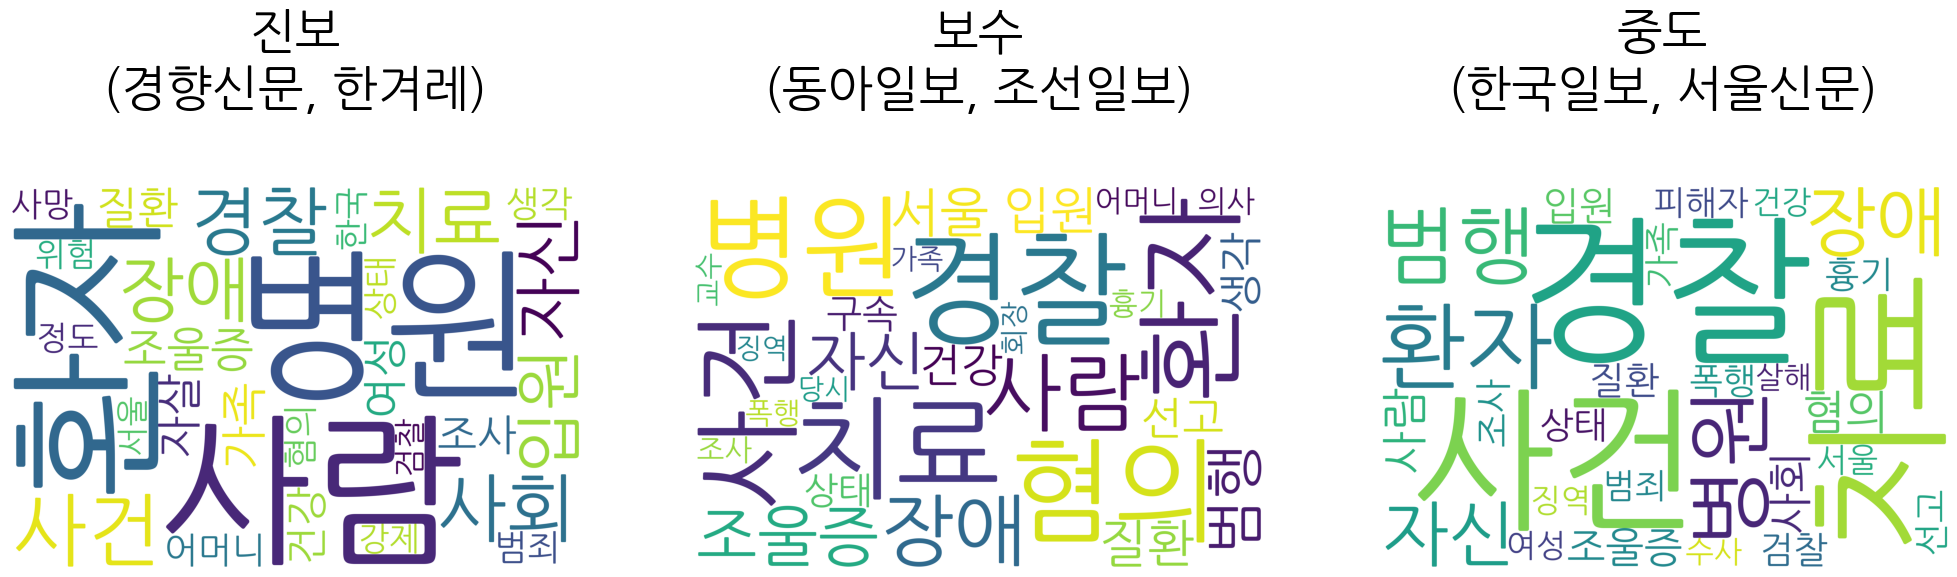

In [ ]:
category = df[df["Group"] == "양극성 장애와 사회적 이슈 및 사건사고"]
category = category[category["Document"].str.contains("범행") | category["Document"].str.contains("혐의") | category["Document"].str.contains("사건")]
category["키워드"] = category["Document"]

liberal = keyword_dataframe(category[category["Partizanship"] == "진보"])
conservative = keyword_dataframe(category[category["Partizanship"] == "보수"])
neutral = keyword_dataframe(category[category["Partizanship"] == "중도"])

wc = WordCloud(width = 3000, height = 2000, random_state=100, background_color="white", font_path="NanumGothic")

fig, ax = plt.subplots(1, 3, figsize=(25, 15))

dataframe = [liberal, conservative, neutral]
partizanship = ["진보", "보수", "중도"]
media_list = [", ".join(category[category["Partizanship"] == p]["press"].unique()) for p in ["진보", "보수", "중도"]]

for i in range(len(dataframe)):
    keywords = dataframe[i][:30].set_index("단어").to_dict()["빈도"]
    keywords.pop("정신")
    
    ax[i].imshow(wc.generate_from_frequencies(keywords))
    ax[i].set_title(f"{partizanship[i]}\n({media_list[i]})", fontsize=35, pad=60)
    ax[i].axis("off")
plt.show()